# DCM labelling of scRNA-seq DEGs

This notebook evaluatues DCM labelling of DEGs identified in de scRNA-seq analysis

## Input

- DCM scores per gene available from GEO (GSE304236_DCMscores.genes.tsv)
- DCM scores per gene body site available from GEO (GSE304236_DCMscores.genesites.txt)

## Output

- Figure S4e. Density of DCM scores
- Figure S6c. Quantification of genome tracks

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## Figure S4e. Density of DCM scores

In [3]:
# DCM scores
dcm = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genes.txt", sep="\t", index_col=0, header=0)
dcm = dcm[dcm["NrSites"] > 10]
dcm = dcm[dcm["GeneName"] != "."]
dcm.index = dcm["GeneName"]
display(dcm)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T48,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000620,0.001612,0.003014,0.042822,0.039482,0.048462,0.001442,0.000000,0.000000,0.046142,...,0.000000,0.000000,0.001749,0.006315,0.043589,0.018845,0.048050,0.012696,TSPAN6,38
TNMD,0.000575,0.000000,0.000000,0.038807,0.034341,0.040833,0.000000,0.001415,0.000705,0.033411,...,0.039010,0.000000,0.000192,0.003627,0.037994,0.008884,0.023858,0.005416,TNMD,41
DPM1,0.004438,0.005045,0.002021,0.103165,0.083093,0.087647,0.004512,0.002730,0.003061,0.086059,...,0.018816,0.000000,0.003835,0.032069,0.091302,0.045974,0.055403,0.055444,DPM1,85
SCYL3,0.001331,0.003211,0.002309,0.051179,0.057704,0.045904,0.002651,0.002339,0.003963,0.047282,...,0.000000,0.000000,0.002284,0.014743,0.051596,0.023948,0.051521,0.034199,SCYL3,124
C1orf112,0.001804,0.002180,0.002140,0.035357,0.040372,0.042450,0.002047,0.001703,0.002777,0.037439,...,0.005692,0.015669,0.002041,0.013985,0.039393,0.022678,0.036709,0.026909,C1orf112,562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMG1P7,0.047153,0.019692,0.024539,0.138187,0.089029,0.091680,0.041089,0.018646,0.010324,0.103718,...,0.429924,0.000000,0.030462,0.177051,0.106298,0.147911,0.069065,0.100861,SMG1P7,14
SMG1P5,0.002655,0.004829,0.004256,0.094638,0.090974,0.089112,0.003702,0.001698,0.003646,0.091200,...,0.048726,0.000000,0.003913,0.030101,0.091575,0.046383,0.075609,0.060821,SMG1P5,222
ANKRD20A11P,0.005164,0.001167,0.002999,0.017392,0.019784,0.017539,0.001826,0.004144,0.004680,0.020352,...,0.000000,0.000000,0.003110,0.030013,0.018238,0.031264,0.023170,0.027319,ANKRD20A11P,105


/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


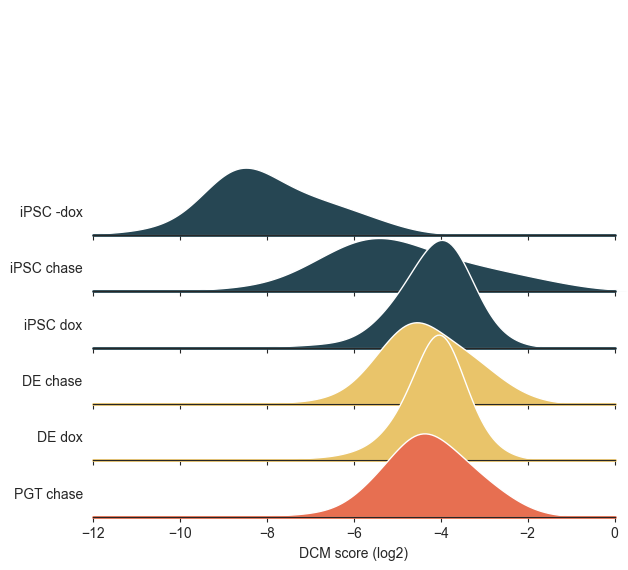

In [4]:
dcm_melt = dcm[["iPSC_nodox", "iPSC_chase", "iPSC_dox", "DE_chase", "DE_dox", "PGT_chase"]].melt(var_name="condition", value_name="DCM score")
dcm_melt["condition"] = dcm_melt["condition"].str.replace("_", " ").str.replace("no", "-")
dcm_melt["DCM score"] = np.log2(dcm_melt["DCM score"])

g = sns.FacetGrid(dcm_melt, row="condition", hue="condition", aspect=6, height=1, palette=[palette["iPSC"]]*3 + [palette["DE"]]*2 + [palette["PGT"]])
g.map(sns.kdeplot, "DCM score", cut=0, bw_adjust=3, clip_on=False, fill=True, alpha=1, linewidth=1, edgecolor="white")

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
g.figure.subplots_adjust(hspace=-0.75)
for ax in g.axes.flat:
    ax.set_facecolor("none")
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="DCM score (log2)", xlim=(-12, 0))
g.despine(bottom=False, left=True)

# Add labels
for ax, label in zip(g.axes.flat, dcm_melt["condition"].unique()):
    ax.text(-0.02, 0.1, label, ha="right", va="center", transform=ax.transAxes)

plt.savefig(f"{output_dir}/SupplementalFigure4e.svg", format="svg", bbox_inches="tight")
plt.show()

In [5]:
# Statistics
results = {}
for celltype in ["iPSC_chase", "iPSC_dox", "DE_chase", "DE_dox", "PGT_chase"]:
    stat, p = scipy.stats.wilcoxon(dcm[celltype], dcm["iPSC_nodox"], alternative="two-sided", nan_policy="omit")
    results[celltype] = {"stat": stat, "pval": p}

results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
print(results_df)

                stat  pval  padj
iPSC_chase  127271.0   0.0   0.0
iPSC_dox    447827.0   0.0   0.0
DE_chase      1312.0   0.0   0.0
DE_dox       76162.0   0.0   0.0
PGT_chase     1560.0   0.0   0.0


## Figure S6c. Quantification of genome tracks

In [6]:
# DCM scores of top DEGs
genes = ["ZFP42", "NANOG", "POU5F1", "EOMES",  "GATA4", "FGF17", "TBX3"]
dcm_degs = dcm.loc[genes]
display(dcm_degs)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T48,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,,,,,,,,,,,,,,
ZFP42,0.001048,0.004765,0.004453,0.143037,0.168239,0.141373,0.003044,0.002578,0.002569,0.176559,...,0.169296,0.000000,0.003422,0.068471,0.150883,0.078406,0.084615,0.056689,ZFP42,45
NANOG,0.001572,0.002042,0.000954,0.191051,0.175035,0.183691,0.005478,0.005801,0.004818,0.178994,...,0.000000,0.225649,0.001523,0.080940,0.183259,0.074376,0.110302,0.067945,NANOG,60
POU5F1,0.001364,0.000253,0.001420,0.032276,0.031093,0.028825,0.000906,0.000000,0.001433,0.036454,...,0.000000,0.000000,0.001012,0.022690,0.030731,0.027416,0.017892,0.017911,POU5F1,121
EOMES,0.001746,0.004538,0.004241,0.044197,0.095746,0.090941,0.000000,0.000000,0.008565,0.069000,...,0.000000,0.000000,0.003509,0.008551,0.076961,0.089534,0.241868,0.144342,EOMES,27
GATA4,0.002653,0.004422,0.004437,0.060691,0.064491,0.061255,0.003315,0.003325,0.004112,0.061076,...,0.029758,0.104464,0.003838,0.039698,0.062146,0.057916,0.163217,0.155610,GATA4,471
FGF17,0.013717,0.014481,0.010931,0.069692,0.078897,0.066966,0.012949,0.008438,0.017344,0.079701,...,0.054718,0.000000,0.013043,0.099084,0.071852,0.089290,0.237780,0.196274,FGF17,55
TBX3,0.001199,0.003115,0.000485,0.044129,0.053596,0.059588,0.001857,0.000983,0.000000,0.056652,...,0.000000,0.000000,0.001600,0.011167,0.052438,0.050116,0.128361,0.117366,TBX3,59


In [7]:
counts = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genesites.txt", sep="\t", header=0, index_col=0)

# Convert all copy-delimited cells to lists
for sample in ["iPSC.nodox", "iPSC.chase", "iPSC.dox", "DE.chase", "DE.dox", "PGT.chase"]:
    counts[sample] = counts[sample].apply(lambda x: [float(i) for i in x.split(",")])
counts.columns = counts.columns.str.replace(".", "_")
counts.index = counts["GeneName"]
display(counts)

,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,
TSPAN6,"[0.0095429849250612, 0.0, 0.0, 0.0095429849250...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.021354493001947698, 0.05803664734947259, 0....","[0.0, 0.0, 0.0, 0.12362132499694485, 0.0, 0.0,...","[0.011100829195214266, 0.05999190706608504, 0....","[0.0, 0.0, 0.0, 0.03290758971931363, 0.0, 0.0,...",TSPAN6,38
TNMD,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00785891...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0416831867240707, 0.0, 0.0, 0.00930082...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06080380...","[0.0, 0.0251288324627852, 0.0, 0.0333024875856...","[0.030057022193231666, 0.0, 0.0, 0.0, 0.0, 0.0...",TNMD,41
DPM1,"[0.0, 0.007858915368142, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.093...","[0.07561250744806076, 0.08818733517010317, 0.0...","[0.05821059613238707, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.02356824544512823, 0.024934832499827933, 0....","[0.0, 0.0, 0.0, 0.030057022193231666, 0.034450...",DPM1,85
SCYL3,"[0.0095429849250612, 0.0, 0.0095429849250612, ...","[0.04654568322711666, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.015327661345577066, 0.0810581511436023, 0.0...","[0.0, 0.0, 0.05821059613238707, 0.0, 0.0, 0.0,...","[0.012467416249913967, 0.03779024867565647, 0....","[0.0, 0.03290758971931363, 0.0, 0.0, 0.0, 0.03...",SCYL3,124
C1orf112,"[0.0, 0.0, 0.0, 0.0, 0.0180695843409495, 0.0, ...","[0.0, 0.10798722435643904, 0.06144154112932237...","[0.009300829689206466, 0.0399561523803607, 0.0...","[0.06080380225004323, 0.11901439838243029, 0.1...","[0.024934832499827933, 0.02356824544512823, 0....","[0.03290758971931363, 0.03290758971931363, 0.0...",C1orf112,562
...,...,...,...,...,...,...,...,...
SMG1P7,"[0.0, 0.0, 0.0, 0.0, 0.007858915368142, 0.0102...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029048335450500267, 0.0564896836603467, 0.0...","[0.0, 0.0, 0.0, 0.06080380225004323, 0.0, 0.0,...","[0.024934832499827933, 0.07089873629834204, 0....","[0.0, 0.0629646119125453, 0.09587220163185893,...",SMG1P7,14
SMG1P5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0556320376761144, 0.0, 0.0, 0.0, 0.11707357...","[0.10689251211279478, 0.06143069248536451, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.1818319211293319, 0.062...","[0.012467416249913967, 0.048891077870870735, 0...","[0.0, 0.06011404438646333, 0.03005702219323166...",SMG1P5,222
ANKRD20A11P,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.111...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06303767...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06080380...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12252298...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.030057022193231666...",ANKRD20A11P,105


In [8]:
# Prepare tables
replicates = ['iPSC_nodox', 'iPSC_dox', 'DE_dox', 'iPSC_chase', 'DE_chase', 'PGT_chase']
dcm_degs_z = dcm_degs[replicates].apply(scipy.stats.zscore, axis=1)
df_z = dcm_degs_z.rename_axis("gene").reset_index().melt(id_vars="gene", var_name="sample", value_name="z-score")
df_raw = dcm_degs[replicates].rename_axis("gene").reset_index().melt(id_vars="gene", var_name="sample", value_name="DCM score")
plot_df = df_z.merge(df_raw, on=["gene", "sample"])
plot_df["sample"] = pd.Categorical(plot_df["sample"], categories=replicates[::-1], ordered=True)
plot_df["percentage"] = plot_df.apply(lambda r: np.sum(np.array(counts.loc[r["gene"], r["sample"]]) > (0.05 if r["gene"] == "POU5F1" else 0.15))
                                                 / counts.loc[r["gene"], "NrSites"], axis=1)               
display(plot_df)

,gene,sample,z-score,DCM score,percentage
0,ZFP42,iPSC_nodox,-1.616631,0.003422,0.000000
1,NANOG,iPSC_nodox,-1.563783,0.001523,0.000000
2,POU5F1,iPSC_nodox,-1.949782,0.001012,0.000000
3,EOMES,iPSC_nodox,-1.107090,0.003509,0.000000
4,GATA4,iPSC_nodox,-1.298159,0.003838,0.000000
5,FGF17,iPSC_nodox,-1.376638,0.013043,0.018182
6,TBX3,iPSC_nodox,-1.216360,0.001600,0.000000
7,ZFP42,iPSC_dox,1.773172,0.150883,0.288889
8,NANOG,iPSC_dox,1.784893,0.183259,0.450000
9,POU5F1,iPSC_dox,1.166141,0.030731,0.206612


/tmp/ipykernel_2244633/3384848614.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


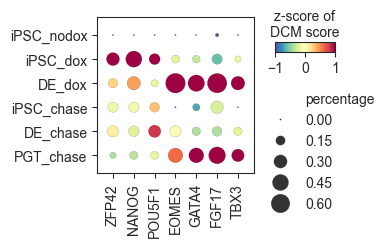

In [9]:
# Plot
plt.figure(figsize=(4, 2.5))

g = sns.scatterplot(data=plot_df, y="sample", x="gene", hue="z-score", size="percentage", 
                    palette="Spectral_r", hue_norm=matplotlib.colors.Normalize(vmin=-1, vmax=1), sizes=(1, 200), edgecolor="black")

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.xlim(-0.75, len(genes) - 0.25)
plt.ylim(-0.75, len(replicates) - 0.25)

# Colorbar
cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-1, vmax=1), cmap="Spectral_r"), 
                        cax=plt.gcf().add_axes([0.7, 0.8, 0.15, 0.04]), orientation="horizontal")
cbar.set_label("z-score of\nDCM score")
cbar.set_ticks([-1, 0, 1])
cbar.ax.xaxis.set_label_position("top")

# Legend
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles[6:], labels=labels[6:], bbox_to_anchor=(1, 0.6), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure6c_bottom.svg", format="svg")
plt.show()